In [1]:
import pickle
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from pathlib import Path
import portion as P

In [2]:
def bin_pext_values(values):
    valid   = [v for v in values if v is not None and not pd.isna(v)]
    missing = [v for v in values if v is None or pd.isna(v)]
    binned  = pd.cut(valid, bins=BIN_EDGES, labels=BIN_LABELS, include_lowest=True)
    counter = Counter(binned)
    counter.update(Counter("none" if v is None else "nan" for v in missing))
    return counter


def count_genes_per_bin(gene_cds_dict, gene_set=None):
    counter = {label: 0 for label in BIN_LABELS}
    counter.update({"none": 0, "nan": 0})
    genes = gene_set if gene_set is not None else gene_cds_dict.keys()
    for gene in genes:
        if gene not in gene_cds_dict:
            continue
        values = gene_cds_dict[gene].values()
        for i, label in enumerate(BIN_LABELS):
            lo, hi = BIN_EDGES[i], BIN_EDGES[i + 1]
            if any(lo <= x < hi for x in values if x is not None and not pd.isna(x)):
                counter[label] += 1
        if any(x is None for x in values):
            counter["none"] += 1
        if any(pd.isna(x) for x in values if x is not None):
            counter["nan"] += 1
    return counter

In [3]:
ROOT = Path("/home/mahe9165/exon-structure-evolution")
PEXT_PKL        = ROOT / "data/pext/GRCh38_v115_human_pext_scores.pkl"
RESULTS_DB      = ROOT / "human_structural_search/Homo_sapiens.GRCh38.115.80.90.80.struct_exonize/Homo_sapiens.GRCh38.115.80.90.80.struct_results.db"
OUTPUT_DIR      = ROOT / "results/figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


with open(PEXT_PKL, "rb") as f:
    pext_gene_cds_dict = pickle.load(f)

# Remove genes where ALL scores are NaN
copy_pext = {
    gene: cds_dict
    for gene, cds_dict in pext_gene_cds_dict.items()
    if not all(pd.isna(v) for v in cds_dict.values())
}

with sqlite3.connect(RESULTS_DB) as db:
    cursor = db.cursor()
    cursor.execute("SELECT GeneID, EventStart, EventEnd, ExpansionID FROM Expansions_full")
    records = cursor.fetchall()

gene_expansions_dict = {}
for gene_id, event_start, event_end, expansion_id in records:
    gene_expansions_dict.setdefault(gene_id, {}).setdefault(expansion_id, []).append(
        P.open(event_start, event_end)
    )

ORANGE  = "#E8A87C"
BLUE    = "#A8BDD0"
FONT    = {"family": "serif", "size": 10}
plt.rcParams.update({"font.family": "serif", "font.size": 10})

BIN_EDGES  = np.arange(0, 1.1, 0.1)
BIN_LABELS = [f"{round(BIN_EDGES[i], 1)}–{round(BIN_EDGES[i+1], 1)}" for i in range(len(BIN_EDGES) - 1)]

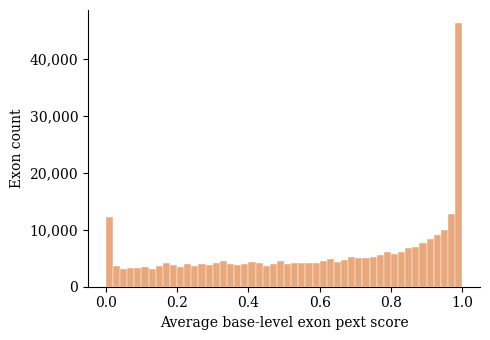

  Total exons with pext scores: 294,590


In [4]:
#  Genome-wide exon pext distribution (histogram)

all_pext = [
    v for cds_dict in pext_gene_cds_dict.values()
    for v in cds_dict.values()
    if v is not None and not pd.isna(v)
]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(all_pext, bins=50, color=ORANGE, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Average base-level exon pext score")
ax.set_ylabel("Exon count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "genome_wide_pext_distribution.pdf", dpi=300)
plt.savefig(OUTPUT_DIR / "genome_wide_pext_distribution.png", dpi=300)
plt.show()
print(f"  Total exons with pext scores: {len(all_pext):,}")

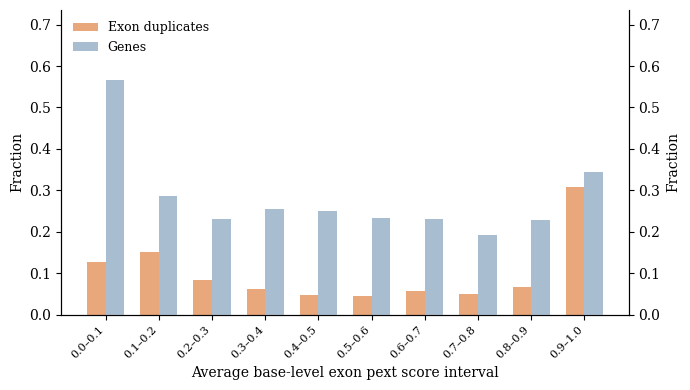

In [5]:
# Figure 3 — Duplicated exons (orange) + genes fraction (blue)

# Exon duplicates
dup_pext_values = [
    pext_gene_cds_dict[gene][cds]
    for gene, events_dict in gene_expansions_dict.items()
    for events in events_dict.values()
    for cds in events
    if gene in pext_gene_cds_dict
]
dup_exons_counter = bin_pext_values(dup_pext_values)

# Gene fractions (genes with at least one dup exon in each bin)
n_genes_with_pext = sum(1 for g in gene_expansions_dict if g in copy_pext)
dup_genes_counter = count_genes_per_bin(pext_gene_cds_dict, gene_set=gene_expansions_dict.keys())

total_dup_exons = sum(dup_exons_counter[l] for l in BIN_LABELS)
exon_fractions  = [dup_exons_counter[l] / total_dup_exons for l in BIN_LABELS]
gene_fractions  = [dup_genes_counter[l] / n_genes_with_pext for l in BIN_LABELS]

x = np.arange(len(BIN_LABELS))
width  = 0.35

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width / 2, exon_fractions, width, color=ORANGE, label="Exon duplicates")
bars2 = ax2.bar(x + width / 2, gene_fractions,  width, color=BLUE,   label="Genes")

ax1.set_xlabel("Average base-level exon pext score interval")
ax1.set_ylabel("Fraction", color="black")
ax2.set_ylabel("Fraction", color="black")
ax1.set_xticks(x)
ax1.set_xticklabels(BIN_LABELS, rotation=45, ha="right", fontsize=8)
ax1.set_ylim(0, max(exon_fractions + gene_fractions) * 1.3)
ax2.set_ylim(0, max(exon_fractions + gene_fractions) * 1.3)

handles = [bars1, bars2]
labels  = ["Exon duplicates", "Genes"]
ax1.legend(handles, labels, loc="upper left", frameon=False, fontsize=9)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "duplicated_exons_pext_distribution.pdf", dpi=300)
plt.savefig(OUTPUT_DIR / "duplicated_exons_pext_distribution.png", dpi=300)
plt.show()


In [6]:
# Stats
genes_in_pext   = sum(1 for g in gene_expansions_dict if g in pext_gene_cds_dict)
pct_in_pext     = genes_in_pext / len(gene_expansions_dict)
print(f"  Genes with exon duplications: {len(gene_expansions_dict)}")
print(f"  Genes with pext data:         {genes_in_pext} ({pct_in_pext:.1%})")
print(f"  Total duplicated exons:       {total_dup_exons:,}")

  Genes with exon duplications: 794
  Genes with pext data:         782 (98.5%)
  Total duplicated exons:       4,872


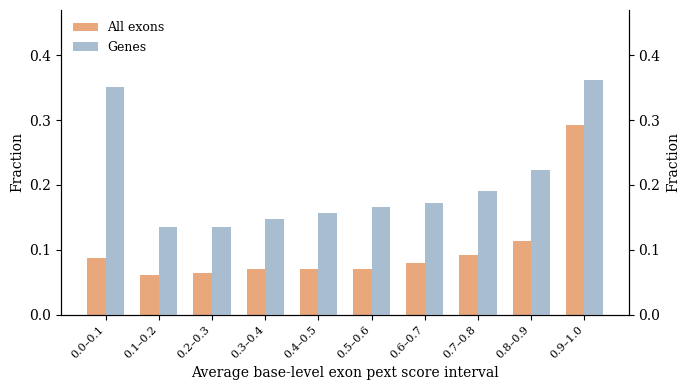

In [7]:
# Genome-wide exon pext binned (with missing breakdown)

all_pext_counter   = bin_pext_values([v for d in pext_gene_cds_dict.values() for v in d.values()])
genome_genes_counter = count_genes_per_bin(pext_gene_cds_dict)
total_exons_all    = sum(all_pext_counter[l] for l in BIN_LABELS)
total_genes_all    = len(pext_gene_cds_dict)

exon_fractions_all = [all_pext_counter[l] / total_exons_all for l in BIN_LABELS]
gene_fractions_all = [genome_genes_counter[l] / total_genes_all for l in BIN_LABELS]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width / 2, exon_fractions_all, width, color=ORANGE, label="All exons")
bars2 = ax2.bar(x + width / 2, gene_fractions_all,  width, color=BLUE,   label="Genes")

ax1.set_xlabel("Average base-level exon pext score interval")
ax1.set_ylabel("Fraction", color="black")
ax2.set_ylabel("Fraction", color="black")
ax1.set_xticks(x)
ax1.set_xticklabels(BIN_LABELS, rotation=45, ha="right", fontsize=8)
ax1.set_ylim(0, max(exon_fractions_all + gene_fractions_all) * 1.3)
ax2.set_ylim(0, max(exon_fractions_all + gene_fractions_all) * 1.3)

handles = [bars1, bars2]
labels  = ["All exons", "Genes"]
ax1.legend(handles, labels, loc="upper left", frameon=False, fontsize=9)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "genome_wide_pext_binned.pdf", dpi=300)
plt.savefig(OUTPUT_DIR / "genome_wide_pext_binned.png", dpi=300)
plt.show()